# Практика: Метод опорных векторов (SVM)

## Что вы сделаете

В этом ноутбуке вы:

1. Загрузите датасет Breast Cancer и проведёте базовый EDA;
2. Обучите **LinearSVC** — быстрый линейный SVM;
3. Исследуете влияние **масштабирования признаков** на качество;
4. Подберёте гиперпараметры (**C**, **kernel**, **gamma**) через `GridSearchCV`;
5. Визуализируете **границу решений** на двух признаках;
6. Проанализируете **ошибки** модели и опорные векторы;
7. Сравните линейный и RBF SVM.

**Датасет:** [Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) — бинарная классификация (злокачественная / доброкачественная опухоль), 569 примеров, 30 числовых признаков.

---
**Как работать:** ячейки с `# YOUR CODE HERE` нужно заполнить самостоятельно. Там же указаны подсказки и ожидаемые результаты.

## Коротко о теории

### Разделяющая гиперплоскость и margin

SVM ищет гиперплоскость $\mathbf{w}^\top \mathbf{x} + b = 0$, максимизирующую зазор (margin):

$$\text{margin} = \frac{2}{\|\mathbf{w}\|}$$

Это эквивалентно задаче:

$$\min_{\mathbf{w},b}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{при} \quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \geq 1 - \xi_i$$

### Ядровой трюк

RBF ядро: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2)$ — позволяет строить нелинейные границы без явного перехода в высокомерное пространство.

### Ключевые параметры

| Параметр | Влияние |
|---|---|
| `C` большой | Узкий margin, мало ошибок на train, риск переобучения |
| `C` малый | Широкий margin, допускает ошибки, лучше обобщение |
| `gamma` большой | Сложная граница, переобучение |
| `gamma` малый | Гладкая граница, недообучение |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Импорты выполнены успешно!')

Импорты выполнены успешно!


In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Размер датасета:', X.shape)
print('Классы:', data.target_names)
print('Распределение классов:')
print(y.value_counts())

display(X.head())

Размер датасета: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Пропуски по признакам:


np.int64(0)


Базовая статистика первых 5 признаков:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163


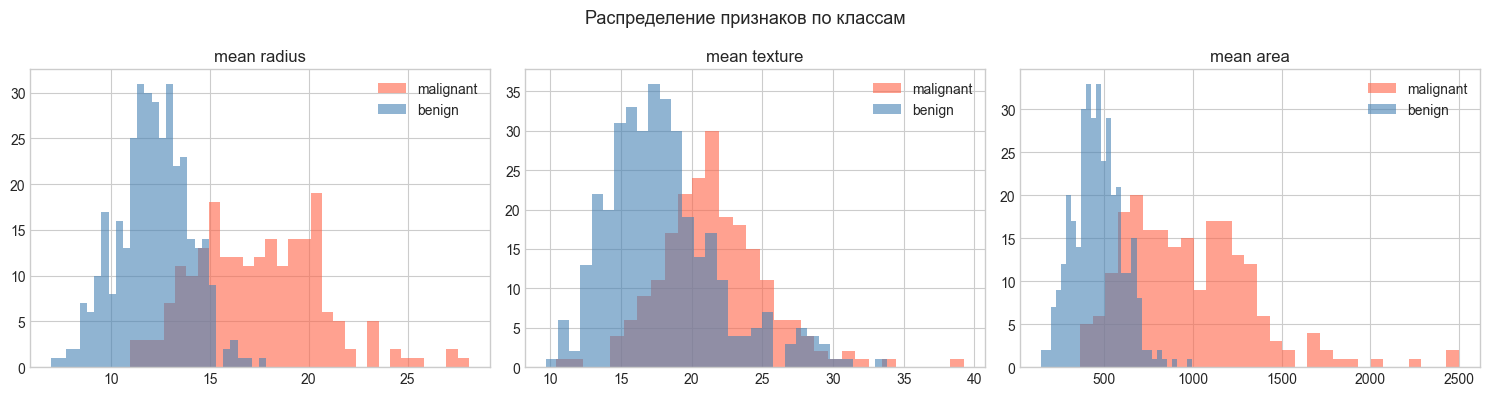

In [4]:
# EDA: базовая статистика и распределения
print('Пропуски по признакам:')
display(X.isna().sum().sum())

print('\nБазовая статистика первых 5 признаков:')
display(X.iloc[:, :5].describe().T.round(3))

# Распределение нескольких признаков по классам
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_to_plot = ['mean radius', 'mean texture', 'mean area']

for ax, feat in zip(axes, features_to_plot):
    for cls, label, color in [(0, 'malignant', 'tomato'), (1, 'benign', 'steelblue')]:
        ax.hist(X.loc[y == cls, feat], bins=30, alpha=0.6, label=label, color=color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Распределение признаков по классам', fontsize=13)
plt.tight_layout()
plt.show()

## Шаг 1. Разделение данных

Разбейте выборку на train и test в соотношении 80/20, зафиксировав `random_state=42`.

Убедитесь, что стратификация сохраняет баланс классов: используйте `stratify=y`.

In [5]:
# YOUR CODE HERE
# Разбейте данные на train/test с stratify=y и random_state=42

X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, random_state = 42)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Баланс классов в train:', y_train.value_counts().to_dict())
print('Баланс классов в test:', y_test.value_counts().to_dict())

Train shape: (426, 30)
Test shape: (143, 30)
Баланс классов в train: {1: 267, 0: 159}
Баланс классов в test: {1: 90, 0: 53}


## Шаг 2. SVM без масштабирования — что будет?

Сначала обучим SVC с RBF ядром **без нормализации** и зафиксируем качество. Потом сравним с нормализованным вариантом.

Используйте `SVC(kernel='rbf', C=1.0, random_state=42)`.

In [6]:
# YOUR CODE HERE
# 1) Создайте SVC(kernel='rbf', C=1.0, random_state=42)
# 2) Обучите на X_train, y_train
# 3) Предскажите на X_test
# 4) Посчитайте и выведите accuracy, f1

svm_no_scale = SVC(kernel= 'rbf', C =1.0, random_state = 42)
svm_no_scale.fit(X_train,y_train)
X_pred = svm_no_scale.predict(X_test)

print('Accuracy без масштабирования:', accuracy_score(y_test,X_pred))
print('F1 без масштабирования:', f1_score(y_test,X_pred))

Accuracy без масштабирования: 0.9230769230769231
F1 без масштабирования: 0.9411764705882353


## Шаг 3. SVM с масштабированием через Pipeline

Теперь постройте Pipeline:
```
StandardScaler → SVC(kernel='rbf', C=1.0, random_state=42)
```

Сравните результат с шагом 2. Ожидаемое улучшение: заметный прирост accuracy и F1.

In [7]:
# YOUR CODE HERE
# Создайте Pipeline с шагами ('scaler', StandardScaler()) и ('svm', SVC(...))
# Обучите и оцените на test

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, random_state=42))
])

# ...
pipe.fit(X_train,y_train)
Y_pred = pipe.predict(X_test)
print('Accuracy С масштабированием:', accuracy_score(y_test,Y_pred))
print('F1 С масштабированием:', f1_score(y_test,Y_pred))
print('\nКлассификационный отчёт:')
print(classification_report(y_test, Y_pred))

Accuracy С масштабированием: 0.9790209790209791
F1 С масштабированием: 0.9832402234636871

Классификационный отчёт:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## Шаг 4. Подбор гиперпараметров через GridSearchCV

Используйте `GridSearchCV` для перебора следующей сетки параметров:

```python
param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 0.01, 0.1],
}
```

Параметры поиска: `cv=5`, `scoring='f1'`.

**Важно:** используйте тот же Pipeline со скейлером, чтобы избежать data leakage!

In [8]:
param_grid = {
    'svm__C':      [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 0.01, 0.1],
}

# YOUR CODE HERE
# 1) Создайте базовый Pipeline с StandardScaler и SVC
# 2) Создайте GridSearchCV с этим pipeline, param_grid, cv=5, scoring='f1'
# 3) Обучите (fit) на train
# 4) Выведите best_params_ и best_score_

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, random_state=42))
])
Search = GridSearchCV(pipe,param_grid, cv =5, scoring = 'f1')

Search.fit(X_train,y_train)
print('Лучшие параметры:',Search.best_params_)
print('CV F1 (best):',Search.best_score_)

Лучшие параметры: {'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV F1 (best): 0.9818160612656026


In [9]:
# Оцените лучшую модель на тестовой выборке
# YOUR CODE HERE
best_model = Search.best_estimator_
y_pred_best = best_model.predict(X_test)

print('Test accuracy (best):', accuracy_score(y_test,y_pred_best))
print('Test F1 (best):', f1_score(y_test,y_pred_best))
print(classification_report(y_test, y_pred_best,
                             target_names=data.target_names))

Test accuracy (best): 0.958041958041958
Test F1 (best): 0.967391304347826
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



## Шаг 5. Confusion Matrix

Визуализируйте матрицу ошибок для лучшей модели.

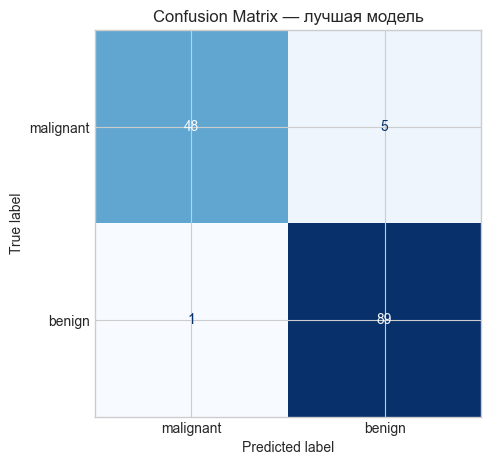

In [10]:
# YOUR CODE HERE
# Постройте ConfusionMatrixDisplay для y_test и y_pred_best
# Добавьте display_labels=data.target_names

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,  # истинные метки
    y_pred_best,  # предсказания
    display_labels= data.target_names,
    ax=ax,
    colorbar=False,
    cmap='Blues'
)
ax.set_title('Confusion Matrix — лучшая модель')
plt.tight_layout()
plt.show()

## Шаг 6. Граница решений на двух признаках

Для визуализации возьмём два признака: `'mean radius'` и `'mean texture'`.

Обучите SVM с RBF ядром и лучшими найденными `C` и `gamma` на этих двух признаках, затем визуализируйте границу решений.

Ниже дана вспомогательная функция — вам нужно её вызвать.

In [11]:
def plot_decision_boundary(model, X_2d, y, title='Граница решений SVM'):
    """Визуализирует границу решений обученной модели на двумерных данных."""
    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25,
                 cmap=mcolors.ListedColormap(['tomato', 'steelblue']))
    plt.contour(xx, yy, Z, colors='k', linewidths=0.8)
    colors = ['tomato' if c == 0 else 'steelblue' for c in y]
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, edgecolors='k', s=40, alpha=0.8)
    plt.xlabel('mean radius (scaled)')
    plt.ylabel('mean texture (scaled)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

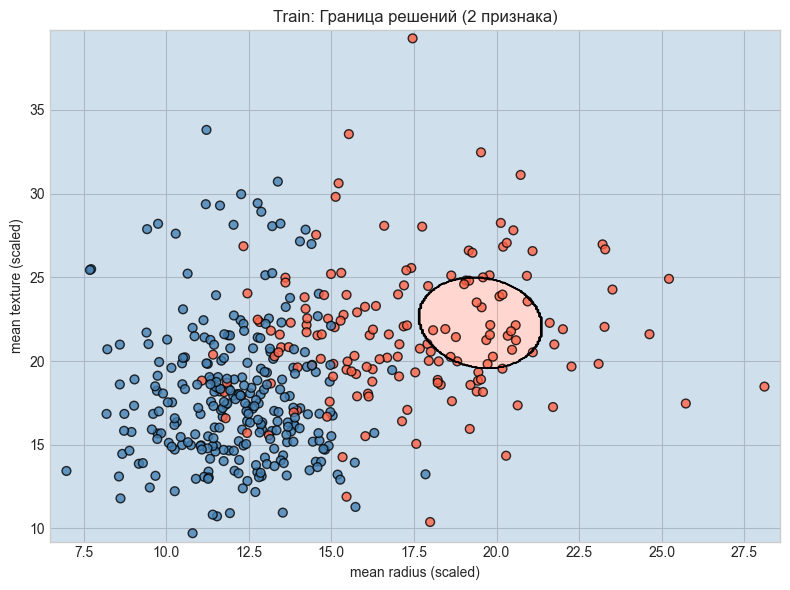

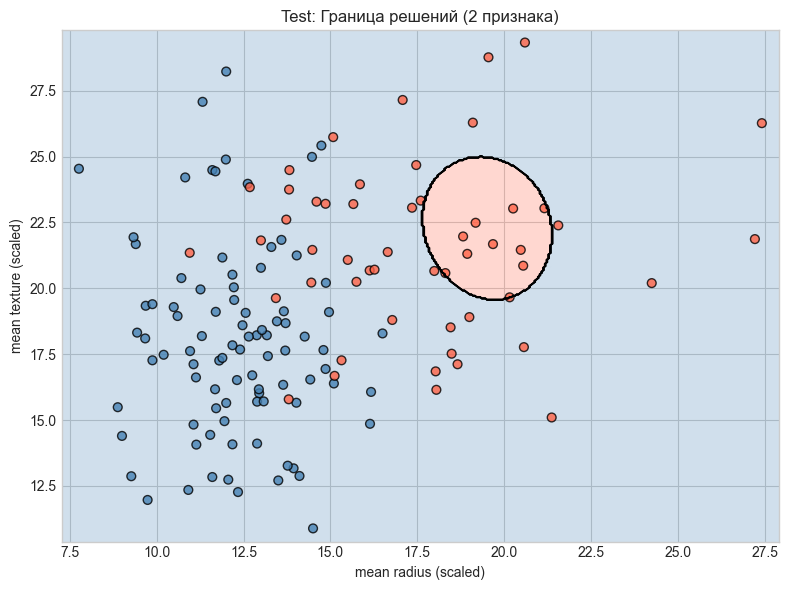

In [12]:
# Выбираем два признака
feat1, feat2 = 'mean radius', 'mean texture'

X_train_2d = X_train[[feat1, feat2]].values
X_test_2d  = X_test[[feat1, feat2]].values

# YOUR CODE HERE
# 1) Создайте Pipeline: StandardScaler + SVC(kernel='rbf', C=<лучший C>, gamma=<лучший gamma>)
# 2) Обучите на X_train_2d, y_train
# 3) Вызовите plot_decision_boundary на тренировочных данных
# 4) Вызовите plot_decision_boundary на тестовых данных

pipe_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C= Search.best_params_['svm__C'],gamma=Search.best_params_['svm__gamma']))
])

pipe_2d.fit(X_train_2d,y_train.values)

plot_decision_boundary(pipe_2d, X_train_2d, y_train.values,
                       title='Train: Граница решений (2 признака)')
plot_decision_boundary(pipe_2d, X_test_2d, y_test.values,
                       title='Test: Граница решений (2 признака)')

## Шаг 7. Анализ ошибок

Найдите примеры, на которых лучшая модель ошиблась. Посмотрите, есть ли у них что-то общее.

1. Выберите неверно классифицированные примеры из тестовой выборки.
2. Выведите их признаки (первые 5 признаков для читаемости).
3. Ответьте в markdown-ячейке: какие классы ошибочно смешиваются?

In [13]:
# YOUR CODE HERE
# 1) Найдите индексы, где y_pred_best != y_test
# 2) Выведите эти строки из X_test (первые 5 признаков)
# 3) Выведите истинный класс и предсказанный
arr = (y_pred_best != y_test.values)
errors_idx = np.where(arr)[0]

print(f'Число ошибочных предсказаний: {len(errors_idx)}')

errors_df = X_test.iloc[errors_idx, :5].copy()
errors_df['true_label'] = y_test.values[errors_idx]
errors_df['pred_label'] = y_pred_best[errors_idx]

display(errors_df)

Число ошибочных предсказаний: 6


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,true_label,pred_label
385,14.60,23.29,93.97,664.7,0.08682,0,1
171,13.43,19.63,85.84,565.4,0.09048,0,1
205,15.12,16.68,98.78,716.6,0.08876,0,1
541,14.47,24.99,95.81,656.4,0.08837,1,0
13,15.85,23.95,103.70,782.7,0.08401,0,1
73,13.80,15.79,90.43,584.1,0.10070,0,1


### Ваш анализ ошибок

**(Ответьте здесь):**
- Сколько ошибок типа False Positive (предсказали «доброкачественная», а на самом деле «злокачественная»)?
- Сколько ошибок типа False Negative?
- Какой тип ошибки более критичен в медицинской задаче? Почему?

5- ложноположительных к 1 - ложноотрицательной
ложноотрицательная будет более критичной, ведь если мы отпустим пациента у которого есть опухоль это будет значительно хуже чем если мы отправим лечится человека у которого, ее нет

## Шаг 8. Линейный vs RBF SVM: сравнение

Сравните два финальных пайплайна:
- `LinearSVC` с подобранным `C`;
- `SVC(kernel='rbf')` с лучшими параметрами.

Используйте **5-fold cross-validation** на тренировочной выборке (метрика `f1`).

In [14]:
# YOUR CODE HERE
# 1) Создайте Pipeline для LinearSVC:
#    StandardScaler + LinearSVC(C=<лучший C>, max_iter=5000, random_state=42)
#
# 2) Создайте Pipeline для RBF SVC с лучшими параметрами
#
# 3) Для каждого пайплайна вычислите cross_val_score(cv=5, scoring='f1')
#    на X_train, y_train
#
# 4) Выведите mean ± std для каждой модели

pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C = Search.best_params_['svm__C'], max_iter = 5000, random_state=42))
])

pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C= Search.best_params_['svm__C'],gamma=Search.best_params_['svm__gamma']))
])

for name, model in [('LinearSVC', pipe_linear), ('RBF SVC', pipe_rbf)]:
    scores = cross_val_score(model,X_train,y_train,cv = 5, scoring='f1')
    print(f'{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')

LinearSVC: F1 = 0.9816 ± 0.0130
RBF SVC: F1 = 0.7706 ± 0.0035


## Шаг 9. Сводная таблица результатов

Соберите итоговую таблицу, сравнивающую все модели:
- SVM без масштабирования (шаг 2)
- SVM со масштабированием (шаг 3)
- Лучшая модель после GridSearch (шаг 4)

In [15]:
# YOUR CODE HERE
# Соберите DataFrame с колонками ['accuracy', 'precision', 'recall', 'f1']
# и строками ['no_scale', 'with_scale', 'best_grid']

def get_metrics(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_test, svm_no_scale.predict(X_test)),   # no_scale
    get_metrics(y_test, Y_pred),   # with_scale
    get_metrics(y_test, y_pred_best),   # best_grid
], index=['no_scale', 'with_scale', 'best_grid'])

display(results.round(4))

,accuracy,precision,recall,f1
no_scale,0.9231,0.9072,0.9778,0.9412
with_scale,0.9790,0.9888,0.9778,0.9832
best_grid,0.9580,0.9468,0.9889,0.9674


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему SVM необходимо масштабировать признаки? Что конкретно ломается без нормализации?
2. Что произойдёт с границей решений, если сильно увеличить параметр `C`? А если уменьшить?
3. Что такое опорные векторы и почему предсказание зависит только от них?
4. В каких случаях стоит выбрать линейное ядро вместо RBF?
5. Почему нельзя обучать `StandardScaler` на всей выборке (train + test) перед кросс-валидацией?

1. Потому что мы используем расстояние между точками, и ломается то, чо вес расстояния по одному признаку будет сильно перевешивать по другому
2. Будет ближе к Hard margin, сильное наказание за миссклассификацию, если сильно уменьшить будет обратное
3. ближайшие к разделяющей гиперплоскости точки данных, что собственно и определяют границу принятия решений
4. Данные +- линейно разделимы
5. Утечка данных, мы для скейлера используем рахличные статистики и используя тестовый данные мы получаем "искажения из будущего"

## Дополнительные задания

### Задание A
Постройте тепловую карту результатов GridSearchCV: ось X — значения `C`, ось Y — значения `gamma`, цвет — CV F1. Используйте `search.cv_results_` и `plt.imshow` или `seaborn.heatmap`.

### Задание B
Исследуйте влияние `C` при фиксированном `gamma='scale'` и `kernel='rbf'`. Постройте график: ось X — `C` (лог-шкала), ось Y — train F1 и test F1 на одном графике. Где начинается переобучение?

### Задание C
Добавьте `class_weight='balanced'` к лучшей модели и сравните recall для класса `malignant` (класс 0). Улучшился ли он? Объясните, почему это важно в медицинской задаче.

### Задание D*
Используйте `RandomizedSearchCV` вместо `GridSearchCV` для более широкой сетки параметров:
```python
from scipy.stats import loguniform
param_dist = {
    'svm__C':     loguniform(1e-3, 1e3),
    'svm__gamma': loguniform(1e-4, 1e1),
    'svm__kernel': ['linear', 'rbf'],
}
```
Сравните время выполнения и итоговое качество с `GridSearchCV`.

<Axes: xlabel='param_svm__C', ylabel='param_svm__gamma'>

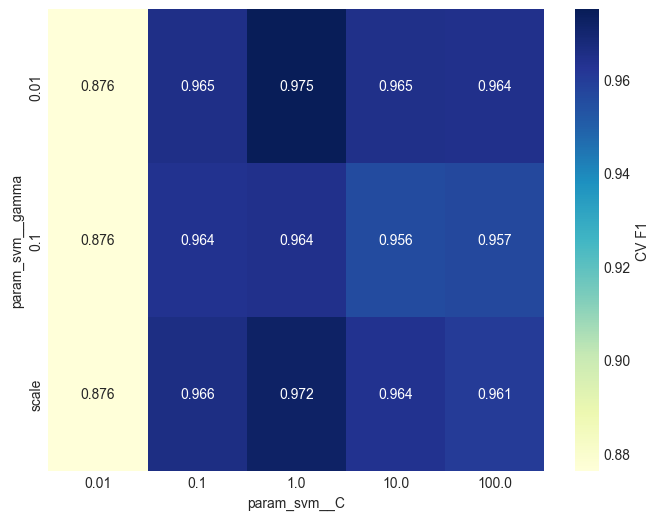

In [31]:
##A
df = pd.DataFrame(Search.cv_results_)
af = df[["param_svm__C", "param_svm__gamma", "mean_test_score"]]
af = af.groupby(["param_svm__C", "param_svm__gamma"], as_index=False).mean()
df = af.pivot(index = "param_svm__gamma", columns = "param_svm__C", values = "mean_test_score")
plt.figure(figsize=(8,6))
sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "CV F1"},
)

In [35]:
##B

f1_trains = []
f1_tests = []
f1_crs_val_trains = []
f1_crs_val_tests = []
param_C =[0.001,0.01,0.05, 0.1, 1,5, 10,50, 100]
for c in param_C :
    pipeB = Pipeline([
    ('scaler',StandardScaler()),
    ('model', SVC(kernel='rbf', C=c, random_state=42))
])

    pipeB.fit(X_train,y_train)
    y_tr_predict = pipeB.predict(X_train)
    y_tst_predict = pipeB.predict(X_test)
    f1_tr = f1_score(y_train,y_tr_predict)
    f1_tst = f1_score(y_test,y_tst_predict)
    f1_crs_val_tr = cross_val_score(pipeB,X_train,y_train,cv =5, scoring = 'f1')
    f1_crs_val_tst = cross_val_score(pipeB,X_test,y_test,cv =5, scoring = 'f1')
    f1_crs_val_trains.append(np.mean(f1_crs_val_tr))
    f1_crs_val_tests.append(np.mean(f1_crs_val_tst))
    f1_trains.append(f1_tr)
    f1_tests.append(f1_tst)

scores = {
    'C_values' : param_C,
    'f1_train_score' : f1_trains,
    'f1_test_score' : f1_tests,
    'f1_cross_val_train' : f1_crs_val_trains,
    'f1_cross_val_test' : f1_crs_val_tests
}
df = pd.DataFrame(scores)
df

,C_values,f1_train_score,f1_test_score,f1_cross_val_train,f1_cross_val_test
0,0.001,0.770563,0.772532,0.770551,0.772618
1,0.010,0.770563,0.772532,0.770551,0.772618
2,0.050,0.961749,0.946237,0.959859,0.779733
3,0.100,0.970588,0.951351,0.957785,0.943278
4,1.000,0.983240,0.983240,0.971877,0.940772
5,5.000,0.992565,0.983240,0.966629,0.956432
6,10.000,0.994413,0.983240,0.968463,0.938275
7,50.000,1.000000,0.960000,0.966594,0.932269
8,100.000,1.000000,0.954545,0.962895,0.932269


<Figure size 1200x800 with 0 Axes>

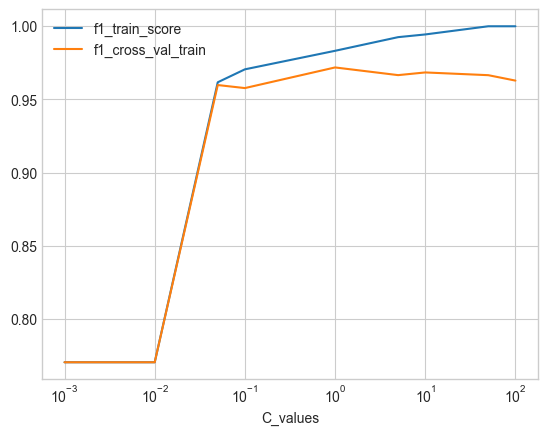

<Figure size 1200x800 with 0 Axes>

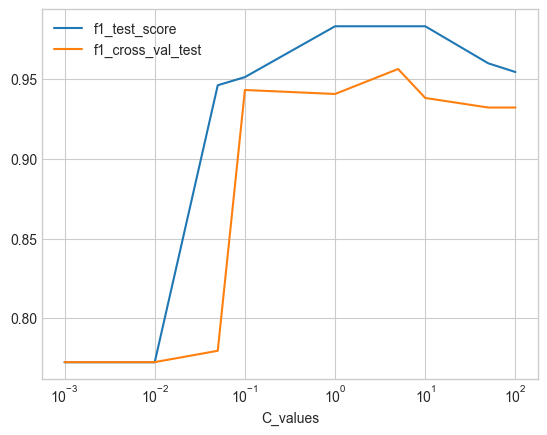

In [43]:
df_train = df[['C_values','f1_train_score','f1_cross_val_train']]
df_test = df[['C_values','f1_test_score','f1_cross_val_test']]
plt.figure(figsize=(12,8))
df_train.plot(x = 'C_values', y = ['f1_train_score','f1_cross_val_train'])
plt.xscale("log")
plt.figure(figsize=(12,8))
df_test.plot(x = 'C_values', y = ['f1_test_score','f1_cross_val_test'])
plt.xscale("log")

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- Загрузка данных и EDA;
- Сравнение SVM с масштабированием и без;
- Подбор гиперпараметров через GridSearchCV;
- Визуализация границы решений на двух признаках;
- Анализ ошибок и confusion matrix;
- Сравнительная таблица линейного и RBF SVM.

**Ожидаемые результаты:**
- SVM без масштабирования: accuracy ≈ 0.63–0.80
- SVM со масштабированием (C=1, rbf): accuracy ≈ 0.97–0.98
- Лучшая модель после GridSearch: F1 ≥ 0.97